In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
def load_data():
    return pd.read_csv("Patient_Comorbidity_Risk_Assessment_Dataset.csv")

df = load_data()

In [125]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,0,170.0,120.0,80.0,89.0,4.9,0,74.0,1.1,4.5
1,PT100002,41,Male,35.1,Never,NaN,NaN,0,0,0,0,174.0,131.0,72.0,81.0,NaN,0,100.0,7.8,7.3
2,PT100003,70,Female,34.6,Never,Low,NaN,0,0,0,0,221.0,135.0,77.0,77.0,5.6,0,88.0,5.4,7.5
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,1,0,0,168.0,165.0,102.0,78.0,5.6,0,93.0,19.7,25.1
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,0,147.0,NaN,70.0,88.0,6.1,0,100.0,11.6,6.3


In [126]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Values': df.isnull().sum().values,
    'Percentage': (df.isnull().sum() / len(df) * 100).values
})

missing_df = missing_df[missing_df['Missing_Values'] > 0]

missing_df

,Column,Missing_Values,Percentage
3,BMI,662,6.62
4,Smoking_Status,615,6.15
5,Alcohol_Consumption,3934,39.34
6,Physical_Activity_Level,738,7.38
11,Cholesterol_Level,577,5.77
12,Systolic_BP,571,5.71
13,Diastolic_BP,571,5.71
14,Resting_Heart_Rate,698,6.98
15,HbA1c,538,5.38
17,Medication_Adherence_Percentage,766,7.66


In [127]:
duplicate_count = pd.DataFrame({
    "Duplicate_Rows": [df.duplicated().sum()]
})

duplicate_count

,Duplicate_Rows
0,0


In [128]:
shape_df = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]]
})

shape_df

,Rows,Columns
0,10000,20


In [129]:
columns_df = pd.DataFrame({
    "Column_Names": df.columns
})

columns_df

,Column_Names
0,Patient_ID
1,Age
2,Gender
3,BMI
4,Smoking_Status
5,Alcohol_Consumption
6,Physical_Activity_Level
7,Diabetes
8,Hypertension
9,Chronic_Kidney_Disease


In [130]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.values
})

dtype_df

,Column,Data_Type
0,Patient_ID,object
1,Age,int64
2,Gender,object
3,BMI,float64
4,Smoking_Status,object
5,Alcohol_Consumption,object
6,Physical_Activity_Level,object
7,Diabetes,int64
8,Hypertension,int64
9,Chronic_Kidney_Disease,int64


In [131]:
skew = pd.DataFrame({
    "Skew": df.skew(numeric_only=True)
})

skew

,Skew
Age,-0.024012
BMI,0.069493
Diabetes,3.033040
Hypertension,1.474676
Chronic_Kidney_Disease,4.036150
Liver_Disease,3.665477
Cholesterol_Level,0.053469
Systolic_BP,0.262859
Diastolic_BP,0.161815
Resting_Heart_Rate,0.055608


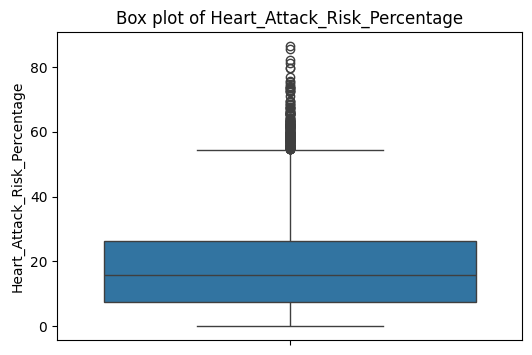

In [132]:
def relation(col):
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title("Box plot of Heart_Attack_Risk_Percentage")
    plt.ylabel("Heart_Attack_Risk_Percentage")
    plt.show()

relation('Heart_Attack_Risk_Percentage')


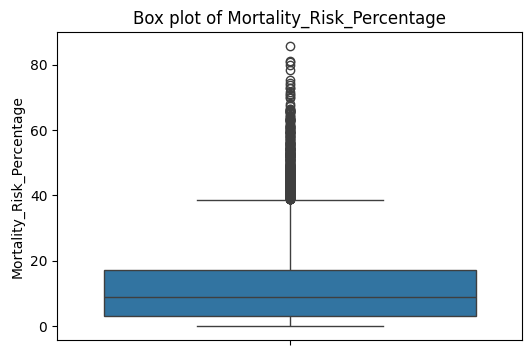

In [133]:
def relation(col):
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title("Box plot of Mortality_Risk_Percentage")
    plt.ylabel("Mortality_Risk_Percentage")
    plt.show()

relation('Mortality_Risk_Percentage')


In [134]:
outlier_summary = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Outlier_Count"])

outlier_df

,Column,Outlier_Count
0,Age,0
1,BMI,38
2,Diabetes,826
3,Hypertension,2033
4,Chronic_Kidney_Disease,520
5,Liver_Disease,611
6,Cholesterol_Level,63
7,Systolic_BP,63
8,Diastolic_BP,63
9,Resting_Heart_Rate,44


In [135]:
outlier_summary = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Outlier_Count"])

outlier_df

,Column,Outlier_Count
0,Age,0
1,BMI,38
2,Diabetes,826
3,Hypertension,2033
4,Chronic_Kidney_Disease,520
5,Liver_Disease,611
6,Cholesterol_Level,63
7,Systolic_BP,63
8,Diastolic_BP,63
9,Resting_Heart_Rate,44


In [136]:
num_cols = df.select_dtypes(include='number').columns

df_capped = df.copy()

for col in num_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower, upper)

print("✅ Outliers handled successfully!")

✅ Outliers handled successfully!


In [137]:
outlier_summary = []

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Outlier_Count"])

outlier_df

,Column,Outlier_Count
0,Age,0
1,BMI,0
2,Diabetes,0
3,Hypertension,0
4,Chronic_Kidney_Disease,0
5,Liver_Disease,0
6,Cholesterol_Level,0
7,Systolic_BP,0
8,Diastolic_BP,0
9,Resting_Heart_Rate,0


In [138]:
df_capped.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Chronic_Kidney_Disease,Liver_Disease,Cholesterol_Level,Systolic_BP,Diastolic_BP,Resting_Heart_Rate,HbA1c,Family_History_CVD,Medication_Adherence_Percentage,Heart_Attack_Risk_Percentage,Mortality_Risk_Percentage
0,PT100001,63,Female,18.8,Former,NaN,High,0,0,0,0,170.0,120.0,80.0,89.0,4.9,0,74.0,1.1,4.5
1,PT100002,41,Male,35.1,Never,NaN,NaN,0,0,0,0,174.0,131.0,72.0,81.0,NaN,0,100.0,7.8,7.3
2,PT100003,70,Female,34.6,Never,Low,NaN,0,0,0,0,221.0,135.0,77.0,77.0,5.6,0,88.0,5.4,7.5
3,PT100004,73,Male,39.8,Never,Low,Moderate,0,0,0,0,168.0,163.5,102.0,78.0,5.6,0,93.0,19.7,25.1
4,PT100005,27,Male,33.1,Current,High,Low,0,0,0,0,147.0,NaN,70.0,88.0,6.1,0,100.0,11.6,6.3


Now, We are starting to use Scikit-learn for build Machine learning model.

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,PowerTransformer
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( r2_score,
                             mean_absolute_error,
                             root_mean_squared_error)
from sklearn.impute import SimpleImputer

In [140]:
def split_data(df):
    X = df.drop(columns=["Patient_ID", "Heart_Attack_Risk_Percentage"])
    y = df["Heart_Attack_Risk_Percentage"]
    return X, y


X, y = split_data(df_capped)

In [141]:
def split_train_test(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_train_test(X, y)

In [142]:
def get_column_types(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()

    return num_cols, cat_cols

num_cols, cat_cols = get_column_types(X_train)

In [143]:
num_cols

['Age',
 'BMI',
 'Diabetes',
 'Hypertension',
 'Chronic_Kidney_Disease',
 'Liver_Disease',
 'Cholesterol_Level',
 'Systolic_BP',
 'Diastolic_BP',
 'Resting_Heart_Rate',
 'HbA1c',
 'Family_History_CVD',
 'Medication_Adherence_Percentage',
 'Mortality_Risk_Percentage']

In [144]:
cat_cols

['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level']

In [145]:
num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("skew",PowerTransformer(method="yeo-johnson")),
    ("scale",StandardScaler())
])

In [146]:
cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("Encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [147]:
preprocessor = ColumnTransformer([
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

In [162]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",SVR())
])

In [163]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [164]:
y_pred = pipeline.predict(X_test)

In [165]:
print(y_pred)

[31.05822199 13.89623345  7.84621144 ... 10.36084755 30.04526429
 40.25284939]


In [166]:
result = pd.DataFrame({
    "Actual":y_test.to_numpy().ravel(),
    "predicated":y_pred
})

In [167]:
print(result.head())

   Actual  predicated
0    34.5   31.058222
1    14.2   13.896233
2     6.7    7.846211
3    24.4   26.318272
4    11.7   13.763825


In [168]:

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.7518077021876736
MAE: 5.191553948600608
RMSE: 6.596334972568691
